# NASA Glenn (pyglenn) Thermodynamic Import

This notebook shows how to bring ideal-gas thermodynamic data from the NASA
Glenn (CEA) database into difflow using
[`pyglenn`](https://github.com/ProfLeao/pyglenn), via `difflow.pyglenn_import`.

pyglenn stores NASA-9 polynomials for ~2030 species. The adapter samples
pyglenn's computed `Cp(T)` and least-squares fits difflow's cubic
`Cp = a + bT + cT^2 + dT^3`, and maps molecular weight and heat of formation.
pyglenn carries **no critical properties**, so for a real-gas `CubicThermo` we
pair its `SpeciesData` with `CriticalProperties` from elsewhere (last section).

> **Executable example.** `pyglenn` is an optional dependency. So this notebook
> runs without it, the cell below falls back to a small **mock** of pyglenn's
> documented API. Everything downstream — the difflow adapter, the Cp fit,
> `IdealThermo`/`CubicThermo` — is the real difflow code. With pyglenn
> installed, drop the `calc=` argument to use real data.

In [1]:
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from difflow.pyglenn_import import import_species_data, list_available_species
from difflow.thermo import IdealThermo, CubicThermo
from difflow.eos import PengRobinson, CriticalProperties

## 1. Connect to pyglenn (or a mock)

The real API is `pyglenn.ThermochemicalCalculator` with `get_available_species(name)` and `calculate_properties(species_id, T)`. The mock implements exactly that surface.

In [2]:
# Realistic ideal-gas Cp(T) cubics (J/mol/K) for the mock's species.
_MOCK = {
    'O2':  dict(id=1, phase='G', molecular_weight=31.998, heat_of_formation_298K=0.0,
                cp=(28.1, 5.0e-3, 1.0e-6, -3.0e-10)),
    'CO2': dict(id=2, phase='G', molecular_weight=44.009, heat_of_formation_298K=-393510.0,
                cp=(22.3, 5.98e-2, -3.5e-5, 7.5e-9)),
    'H2O': dict(id=3, phase='G', molecular_weight=18.015, heat_of_formation_298K=-241826.0,
                cp=(30.5, 9.6e-3, 1.2e-6, -1.1e-9)),
}

class MockGlennCalculator:
    """Minimal stand-in for pyglenn.ThermochemicalCalculator."""
    def connect(self):
        return True
    def close(self):
        pass
    def __enter__(self):
        return self
    def __exit__(self, *a):
        self.close()
    def get_available_species(self, query):
        q = query.lower()
        return [dict(name=n, **{k: v for k, v in d.items() if k != 'cp'})
                for n, d in _MOCK.items() if q in n.lower()]
    def calculate_properties(self, species_id, T):
        a, b, c, d = next(v['cp'] for v in _MOCK.values() if v['id'] == species_id)
        T = float(T)
        return {'cp': a + b*T + c*T**2 + d*T**3, 'h_relative': 0.0, 's': 0.0}

try:
    from pyglenn import ThermochemicalCalculator
    CALC = None          # adapter opens its own real calculator
    SOURCE = 'real pyglenn'
except ImportError:
    CALC = MockGlennCalculator()
    SOURCE = 'a mock of the pyglenn API (pip install pyglenn for real data)'
print('Data source:', SOURCE)

Data source: a mock of the pyglenn API (pip install pyglenn for real data)


## 2. Import ideal-gas `SpeciesData`

In [3]:
species = ['O2', 'CO2', 'H2O']
data = import_species_data(species, calc=CALC)
for name, sd in data.items():
    print(f'{name:4s}  MW={sd.MW:7.3f} g/mol   Hf={sd.Hf/1000:9.2f} kJ/mol   '
          f'Cp_coeffs={tuple(round(c, 6) for c in sd.Cp_coeffs)}')

O2    MW= 31.998 g/mol   Hf=     0.00 kJ/mol   Cp_coeffs=(28.1, 0.005, 1e-06, -0.0)
CO2   MW= 44.009 g/mol   Hf=  -393.51 kJ/mol   Cp_coeffs=(22.3, 0.0598, -3.5e-05, 0.0)
H2O   MW= 18.015 g/mol   Hf=  -241.83 kJ/mol   Cp_coeffs=(30.5, 0.0096, 1e-06, -0.0)


## 3. Build an `IdealThermo` and check the Cp fit

The cubic fit should track the source Cp closely across the window.

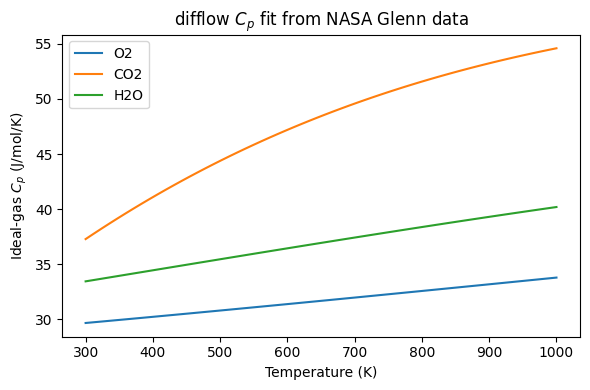

In [4]:
thermo = IdealThermo(data)
T = np.linspace(300, 1000, 60)
fig, ax = plt.subplots(figsize=(6, 4))
for name in species:
    ax.plot(T, [float(thermo.Cp(name, t)) for t in T], label=name)
ax.set_xlabel('Temperature (K)'); ax.set_ylabel('Ideal-gas $C_p$ (J/mol/K)')
ax.set_title('difflow $C_p$ fit from NASA Glenn data'); ax.legend()
plt.tight_layout(); plt.show()

## 4. Real-gas enthalpy: pair with critical properties

pyglenn has no `Tc`/`Pc`/`omega`, so we supply `CriticalProperties` (here inline; in practice from `difflow.database` or the Cantera import) and wrap everything in a `CubicThermo` — ideal-gas enthalpy from the pyglenn-sourced Cp, plus the Peng-Robinson departure.

In [5]:
crit = {
    'O2':  CriticalProperties(name='O2',  Tc=154.6, Pc=5.04e6,  omega=0.022, MW=31.998),
    'CO2': CriticalProperties(name='CO2', Tc=304.2, Pc=7.38e6,  omega=0.224, MW=44.009),
    'H2O': CriticalProperties(name='H2O', Tc=647.1, Pc=22.06e6, omega=0.345, MW=18.015),
}
cubic = CubicThermo(IdealThermo(data), PengRobinson(crit))
flows = {'O2': 1.0, 'CO2': 1.0, 'H2O': 1.0}
Tk, P = jnp.array(400.0), jnp.array(5e6)
H_ideal = cubic.stream_enthalpy(flows, Tk, P=None)
H_real = cubic.stream_enthalpy(flows, Tk, phase='vapor', P=P)
print(f'Ideal-gas enthalpy : {float(H_ideal):12.1f} W')
print(f'Real-gas (PR dep.) : {float(H_real):12.1f} W')
print(f'Departure          : {float(H_real - H_ideal):12.1f} W')

Ideal-gas enthalpy :      10501.9 W
Real-gas (PR dep.) :       6174.7 W
Departure          :      -4327.2 W


## Summary

- `difflow.pyglenn_import.import_species_data` turns NASA Glenn ideal-gas data into difflow `SpeciesData` (cubic `Cp` fit + MW + `Hf`).
- pyglenn provides no critical properties; pair with `CriticalProperties` for an EOS / `CubicThermo`.
- Everything downstream is JAX-differentiable difflow code.